In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from src.amp_colabfold.structure_utils import (
    build_structure_summary, classify_confidence,
    parse_pdb_plddt, parse_pae_json,
    STRUCTURES_DIR, PROCESSED_DIR, RESULTS_DIR
)

print("Imports OK")
print(f"Structures dir: {STRUCTURES_DIR}")

Imports OK
Structures dir: D:\Github_projects\amp-colabfold\structures\colabfold_output\flat_files


In [2]:
df_struct = build_structure_summary()
df_struct["confidence"] = df_struct["mean_plddt"].apply(classify_confidence)

print(f"Structures parsed: {len(df_struct)}")
print(f"\nConfidence distribution:")
print(df_struct["confidence"].value_counts())
print(f"\nTop 10 by pLDDT:")
df_struct[["amp_id","length","mean_plddt","ptm","confidence"]].head(10)

Found 131 scores JSON files
Structures parsed: 131

Confidence distribution:
confidence
Very high    69
Confident    52
Low          10
Name: count, dtype: int64

Top 10 by pLDDT:


,amp_id,length,mean_plddt,ptm,confidence
0,AMP_02388,30,97.333000,0.54,Very high
1,AMP_01454,36,97.241111,0.60,Very high
2,AMP_02689,28,97.197857,0.50,Very high
3,AMP_02834,27,97.157037,0.48,Very high
4,AMP_01282,37,97.108108,0.61,Very high
5,AMP_01129,38,97.039211,0.62,Very high
6,AMP_01781,34,96.988529,0.58,Very high
7,AMP_01433,36,96.952778,0.60,Very high
8,AMP_02526,29,96.859310,0.52,Very high
9,AMP_02105,32,96.849375,0.57,Very high


In [3]:
out_path = PROCESSED_DIR / "structure_summary.csv"
df_struct.drop(columns="plddt_per_residue").to_csv(out_path, index=False)
print(f"Saved → {out_path}")

Saved → D:\Github_projects\amp-colabfold\data\processed\structure_summary.csv


In [4]:
fig = px.histogram(
    df_struct,
    x="mean_plddt",
    color="confidence",
    nbins=30,
    title="pLDDT distribution across 131 AMP candidates",
    labels={"mean_plddt": "Mean pLDDT", "count": "Count"},
    color_discrete_map={
        "Very high": "#2166ac",
        "Confident": "#74add1",
        "Low":       "#fdae61",
        "Very low":  "#d73027",
    },
    template="simple_white",
)
fig.add_vline(x=70, line_dash="dash", line_color="grey", annotation_text="pLDDT=70")
fig.add_vline(x=90, line_dash="dash", line_color="grey", annotation_text="pLDDT=90")
fig.write_image(str(RESULTS_DIR / "figures" / "plddt_distribution.png"))
fig.show()

In [5]:
fig = px.scatter(
    df_struct,
    x="ab_proba",
    y="mean_plddt",
    color="confidence",
    hover_data=["amp_id", "length", "ptm"],
    title="Predicted antibacterial probability vs structural confidence",
    labels={
        "ab_proba":   "Antibacterial probability (classifier)",
        "mean_plddt": "Mean pLDDT (ColabFold)",
    },
    color_discrete_map={
        "Very high": "#2166ac",
        "Confident": "#74add1",
        "Low":       "#fdae61",
        "Very low":  "#d73027",
    },
    template="simple_white",
)
fig.add_hline(y=70, line_dash="dash", line_color="grey")
fig.write_image(str(RESULTS_DIR / "figures" / "plddt_vs_abproba.png"))
fig.show()

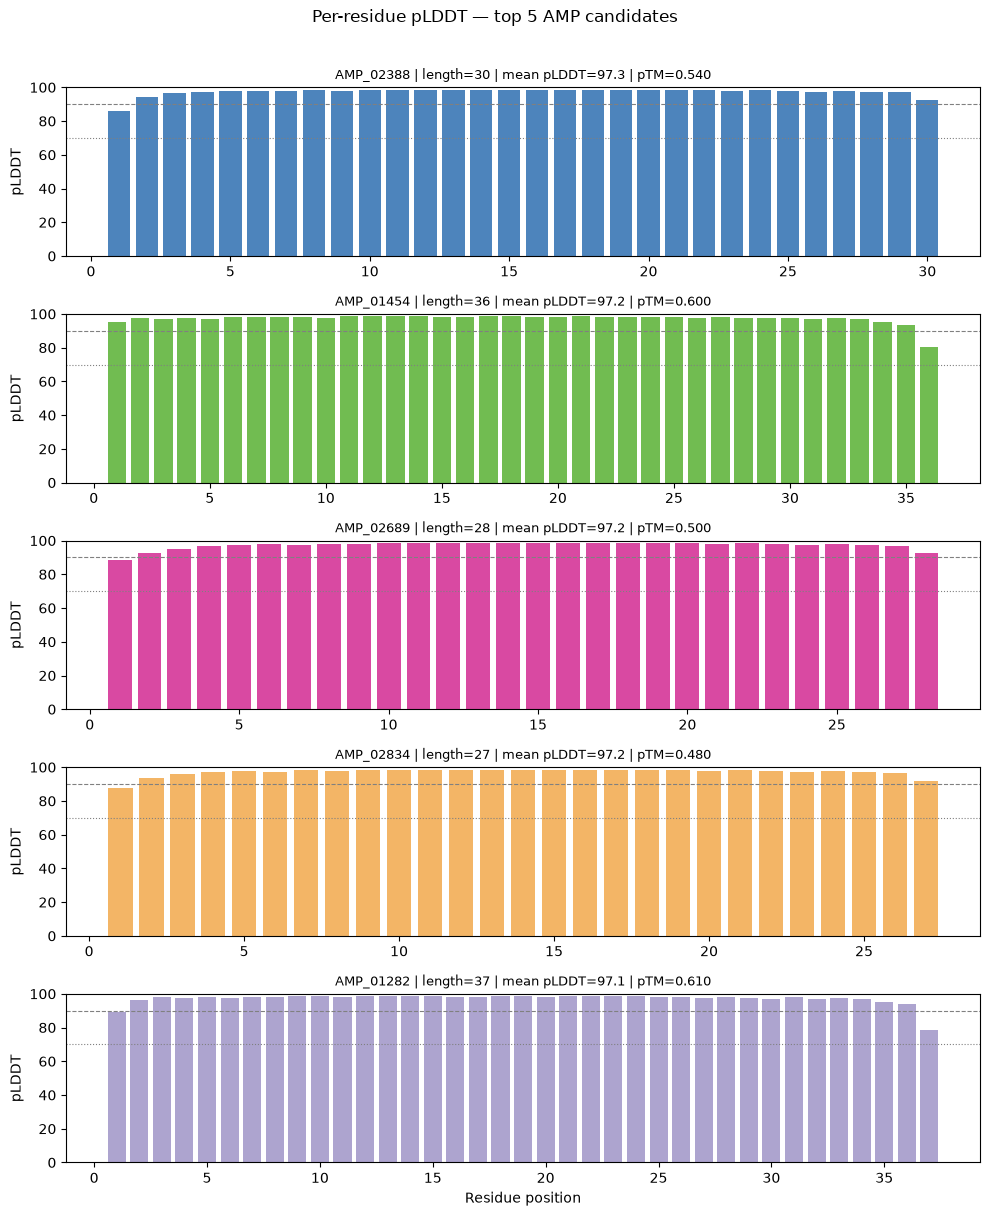

Saved → results/figures/plddt_per_residue_top5.png


In [6]:
top5 = df_struct.head(5)

fig, axes = plt.subplots(5, 1, figsize=(10, 12))
colors = ["#2166ac", "#4dac26", "#d01c8b", "#f1a340", "#998ec3"]

for i, (_, row) in enumerate(top5.iterrows()):
    plddt = row["plddt_per_residue"]
    x = list(range(1, len(plddt) + 1))
    axes[i].bar(x, plddt, color=colors[i], alpha=0.8, width=0.8)
    axes[i].axhline(y=90, color="grey", linestyle="--", linewidth=0.8)
    axes[i].axhline(y=70, color="grey", linestyle=":",  linewidth=0.8)
    axes[i].set_ylim(0, 100)
    axes[i].set_ylabel("pLDDT")
    axes[i].set_title(
        f"{row['amp_id']} | length={row['length']} | "
        f"mean pLDDT={row['mean_plddt']:.1f} | pTM={row['ptm']:.3f}",
        fontsize=9
    )

axes[-1].set_xlabel("Residue position")
plt.suptitle("Per-residue pLDDT — top 5 AMP candidates", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / "plddt_per_residue_top5.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/figures/plddt_per_residue_top5.png")

In [7]:
# High-confidence candidates: pLDDT >= 70 AND ab_proba >= 0.95
final_candidates = df_struct[
    (df_struct["mean_plddt"] >= 70) &
    (df_struct["ab_proba"] >= 0.95)
].copy()

print(f"Final high-confidence candidates: {len(final_candidates)}")
print(f"  pLDDT >= 90 (Very high): {(final_candidates['mean_plddt'] >= 90).sum()}")
print(f"  pLDDT 70-90 (Confident): {(final_candidates['mean_plddt'] < 90).sum()}")

final_candidates.drop(columns="plddt_per_residue").to_csv(
    RESULTS_DIR / "candidate_amps.csv", index=False
)
print(f"\nSaved → results/candidate_amps.csv")
final_candidates[["amp_id","length","mean_plddt","ptm","ab_proba","confidence"]].head(15)

Final high-confidence candidates: 69
  pLDDT >= 90 (Very high): 47
  pLDDT 70-90 (Confident): 22

Saved → results/candidate_amps.csv


,amp_id,length,mean_plddt,ptm,ab_proba,confidence
0,AMP_02388,30,97.333000,0.54,0.9523,Very high
1,AMP_01454,36,97.241111,0.60,0.9849,Very high
2,AMP_02689,28,97.197857,0.50,0.9541,Very high
4,AMP_01282,37,97.108108,0.61,0.9811,Very high
5,AMP_01129,38,97.039211,0.62,0.9591,Very high
6,AMP_01781,34,96.988529,0.58,0.9623,Very high
7,AMP_01433,36,96.952778,0.60,0.9623,Very high
8,AMP_02526,29,96.859310,0.52,0.9514,Very high
9,AMP_02105,32,96.849375,0.57,0.9754,Very high
12,AMP_01647,35,96.808000,0.59,0.9774,Very high
